# Student Performance Analysis Using Data Science

## Project Objective

This project analyzes student academic performance using a real-world
student dataset. The objective is to identify patterns and relationships
between factors such as study hours, attendance, assignment scores,
and final grades.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("student_data.csv")

In [3]:
df.head()

,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,36.0,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,71841.0,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR


In [4]:
df.shape

(42, 5)

In [5]:
df.columns

Index(['Name', 'Age', 'Salary', 'Join_Date', 'Department'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        42 non-null     str    
 1   Age         42 non-null     float64
 2   Salary      42 non-null     float64
 3   Join_Date   42 non-null     str    
 4   Department  42 non-null     str    
dtypes: float64(2), str(3)
memory usage: 2.4 KB


In [7]:
df.describe()

,Age,Salary
count,42.000000,42.000000
mean,34.690476,124031.309524
std,9.238013,183008.178720
min,21.000000,61000.000000
25%,25.000000,68500.000000
50%,36.000000,71841.000000
75%,40.750000,77421.000000
max,57.000000,921000.000000


In [8]:
df.isnull().sum()

Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64

In [9]:
(df.isnull().sum() / len(df)) * 100

Name          0.0
Age           0.0
Salary        0.0
Join_Date     0.0
Department    0.0
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Final_Grade"].mean()

KeyError: 'Final_Grade'

In [14]:
print(df.columns.tolist())

['Name', 'Age', 'Salary', 'Join_Date', 'Department']


In [15]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Name', 'Age', 'Salary', 'Join_Date', 'Department']


In [16]:
df["Final_Grade"].mean()

KeyError: 'Final_Grade'

In [17]:
# Clean all column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['Name', 'Age', 'Salary', 'Join_Date', 'Department']


In [18]:
df["Final_Grade"].mean()

KeyError: 'Final_Grade'

In [19]:
df["Salary"].mean()

np.float64(124031.30952380953)

In [20]:
df["Age"].mean()

np.float64(34.69047619047619)

In [21]:
df["Salary"].max()

921000.0

In [22]:
df["Salary"].min()

61000.0

In [23]:
df["Salary"].describe()

count        42.000000
mean     124031.309524
std      183008.178720
min       61000.000000
25%       68500.000000
50%       71841.000000
75%       77421.000000
max      921000.000000
Name: Salary, dtype: float64

In [24]:
df["Department"].value_counts()

Department
HR         22
Finance    10
IT         10
Name: count, dtype: int64

In [25]:
df.groupby("Department")["Salary"].mean()

Department
Finance     65614.1
HR          95294.0
IT         245670.6
Name: Salary, dtype: float64

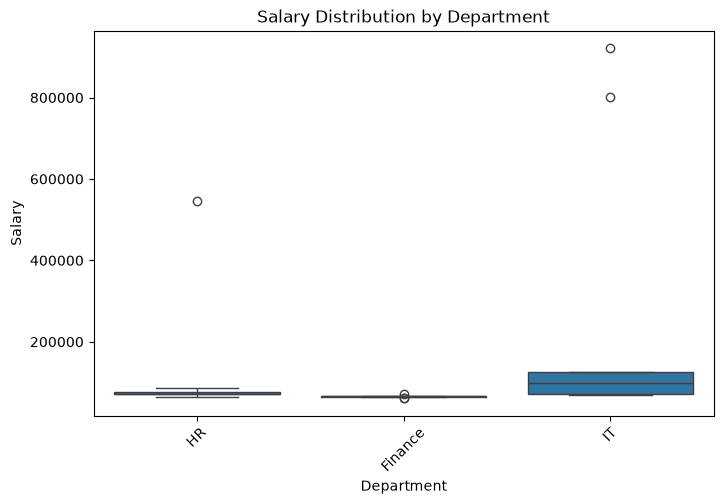

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Department", y="Salary")
plt.title("Salary Distribution by Department")
plt.xticks(rotation=45)
plt.show()

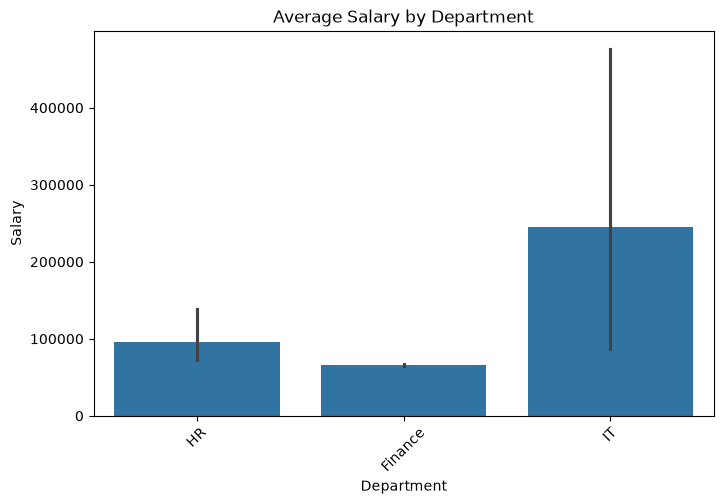

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Department", y="Salary")
plt.title("Average Salary by Department")
plt.xticks(rotation=45)
plt.show()

In [28]:
department_count = df["Department"].value_counts()

department_count

Department
HR         22
Finance    10
IT         10
Name: count, dtype: int64

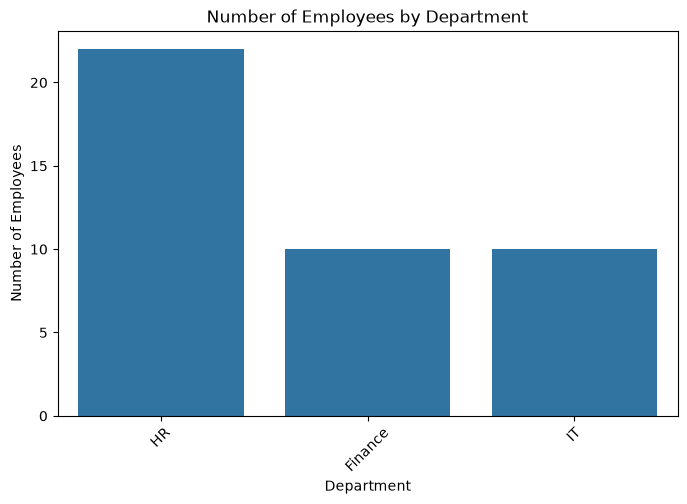

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department"
)

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45)

plt.show()

In [30]:
avg_salary = df.groupby("Department")["Salary"].mean().sort_values(ascending=False)

avg_salary

Department
IT         245670.6
HR          95294.0
Finance     65614.1
Name: Salary, dtype: float64

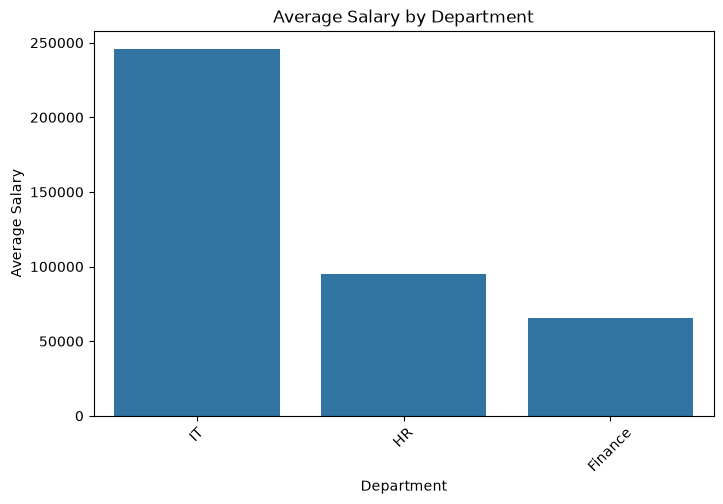

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_salary.index,
    y=avg_salary.values
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

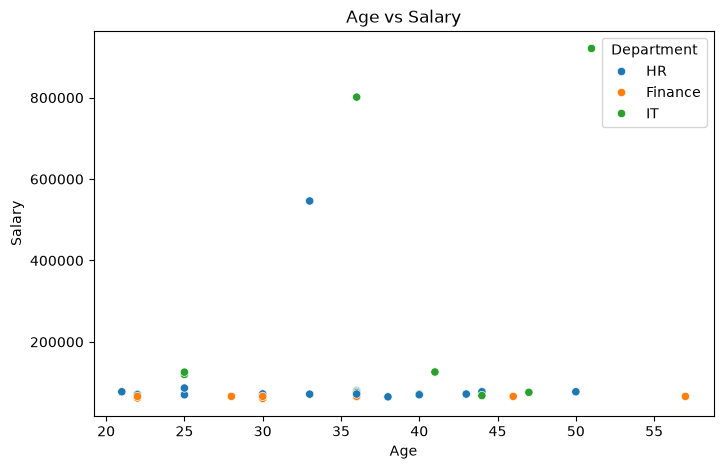

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Salary",
    hue="Department"
)

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

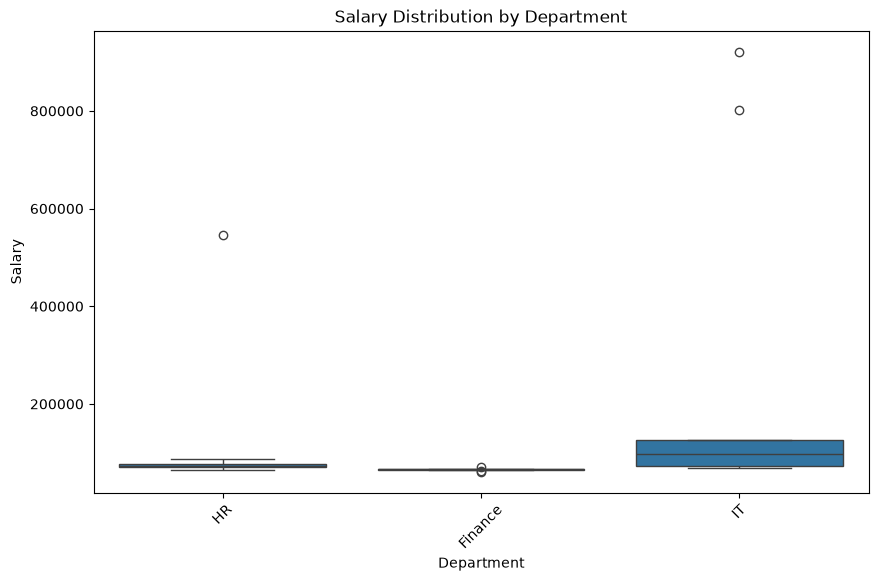

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Department",
    y="Salary"
)

plt.title("Salary Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Salary")

plt.xticks(rotation=45)

plt.show()

In [34]:
df["Join_Year"] = df["Join_Date"].dt.year

AttributeError: Can only use .dt accessor with datetimelike values

In [35]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"], errors="coerce")

In [36]:
df["Join_Year"] = df["Join_Date"].dt.year

In [37]:
print(df[["Join_Date", "Join_Year"]].head())

   Join_Date  Join_Year
0 2023-01-15       2023
1 2022-08-01       2022
2 2021-05-20       2021
3 2023-01-15       2023
4 2023-01-15       2023


In [38]:
df["Join_Month"] = df["Join_Date"].dt.month

In [39]:
df["Join_Month_Name"] = df["Join_Date"].dt.month_name()

In [40]:
import pandas as pd

# Convert Join_Date to datetime
df["Join_Date"] = pd.to_datetime(df["Join_Date"], errors="coerce")

# Extract year and month
df["Join_Year"] = df["Join_Date"].dt.year
df["Join_Month"] = df["Join_Date"].dt.month
df["Join_Month_Name"] = df["Join_Date"].dt.month_name()

# Display result
print(df.head())

    Name   Age   Salary  Join_Date Department  Join_Year  Join_Month  \
0    Pam  25.0  70200.0 2023-01-15         HR       2023           1   
1   Jane  36.0  65000.0 2022-08-01    Finance       2022           8   
2  Alice  22.0  71350.0 2021-05-20         HR       2021           5   
3    Bob  22.0  71841.0 2023-01-15         IT       2023           1   
4    Pam  25.0  71250.0 2023-01-15         HR       2023           1   

  Join_Month_Name  
0         January  
1          August  
2             May  
3         January  
4         January  


In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=join_year_count.index,
    y=join_year_count.values
)

plt.title("Employees Joined by Year")
plt.xlabel("Join Year")
plt.ylabel("Number of Employees")

plt.show()

NameError: name 'join_year_count' is not defined

<Figure size 800x500 with 0 Axes>

In [42]:
join_year_count = df["Join_Year"].value_counts().sort_index()

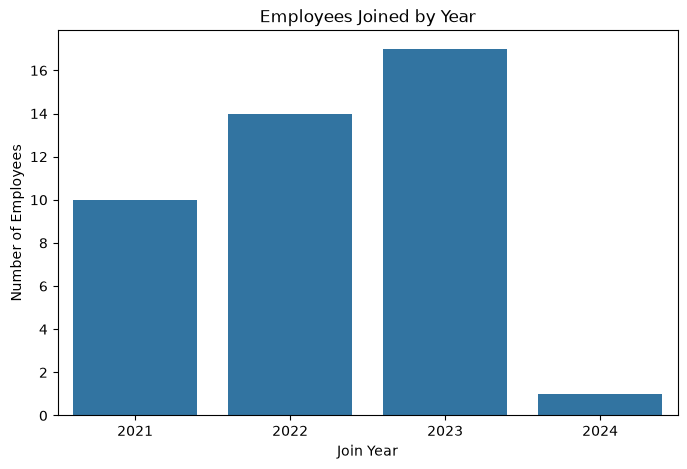

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=join_year_count.index,
    y=join_year_count.values
)

plt.title("Employees Joined by Year")
plt.xlabel("Join Year")
plt.ylabel("Number of Employees")

plt.show()

In [44]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"], errors="coerce")

In [45]:
df["Join_Year"] = df["Join_Date"].dt.year

In [46]:
join_year_count = df["Join_Year"].value_counts().sort_index()

In [47]:
print(join_year_count)

Join_Year
2021    10
2022    14
2023    17
2024     1
Name: count, dtype: int64


In [48]:
numeric_columns = df.select_dtypes(include=np.number)

numeric_columns.corr()

,Age,Salary,Join_Year,Join_Month
Age,1.000000,0.194878,0.112203,0.085078
Salary,0.194878,1.000000,-0.370159,0.010385
Join_Year,0.112203,-0.370159,1.000000,-0.447924
Join_Month,0.085078,0.010385,-0.447924,1.000000


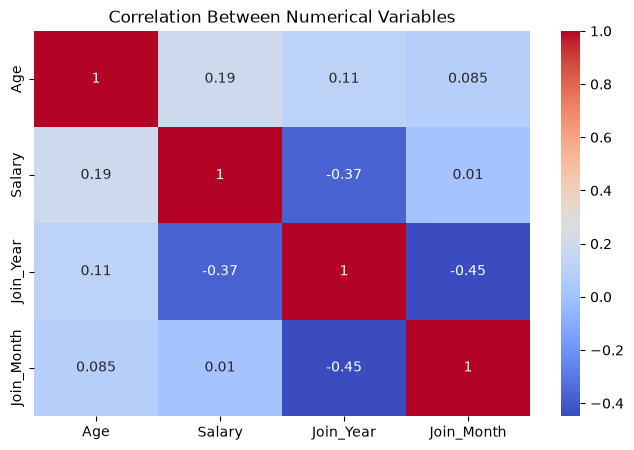

In [49]:
plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [50]:
df.sort_values("Salary", ascending=False).head(5)

,Name,Age,Salary,Join_Date,Department,Join_Year,Join_Month,Join_Month_Name
21,Norma,51.0,921000.0,2021-02-04,IT,2021,2,February
28,Jenny,36.0,801423.0,2021-09-15,IT,2021,9,September
41,Kim,33.0,546222.0,2021-08-30,HR,2021,8,August
15,Susy,41.0,126001.0,2023-02-02,IT,2023,2,February
18,Joanne,25.0,125600.0,2023-01-16,IT,2023,1,January


In [51]:
df.sort_values("Salary", ascending=True).head(5)

,Name,Age,Salary,Join_Date,Department,Join_Year,Join_Month,Join_Month_Name
22,Anthony,30.0,61000.0,2021-08-06,Finance,2021,8,August
10,Joe,22.0,62000.0,2022-10-09,Finance,2022,10,October
1,Jane,36.0,65000.0,2022-08-01,Finance,2022,8,August
32,Jimmy,38.0,65000.0,2024-10-03,HR,2024,10,October
30,Anthony,30.0,66000.0,2021-08-06,Finance,2021,8,August


# Findings and Conclusion

## Findings

1. The dataset contains employee information including name, age,
   salary, joining date, and department.

2. The distribution of employees across departments was analyzed.

3. Department-wise average salaries were calculated to compare salary
   patterns across departments.

4. Salary distribution was examined using histograms and box plots.

5. The relationship between employee age and salary was investigated
   using scatter plots.

6. Joining-year analysis was performed to understand employee joining
   trends.

7. Correlation analysis was used to examine relationships between
   numerical variables.

## Conclusion

This project demonstrates an end-to-end data analysis workflow using
a real-world employee dataset. The analysis includes data loading,
data cleaning, exploratory data analysis, statistical analysis, and
visualization.

The results provide insights into employee demographics, salary
patterns, departmental differences, and joining trends.